# Análise Exploratória de Dados - BNDES

In [1]:
# =========================
# Importação das bibliotecas
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração global de tamanho
plt.rcParams['figure.figsize'] = (10,5)


In [2]:
# =========================
# Definição das pastas
# =========================
PASTA_DATA = "../Data"
PASTA_RESULTADOS = "../Resultados"

# Criar pasta de resultados caso não exista, isso facilita o uso do git em grupo
os.makedirs(PASTA_RESULTADOS, exist_ok=True)


In [3]:
# =========================
# Leitura do dataset (CSV)
# =========================


# O uso de sep=';' garante a acurácia na separação das colunas financeiras.
dados = pd.read_csv(os.path.join(PASTA_DATA, 'bndes_dre.csv'), sep=';', skiprows=3)

# Limpeza de Atributos: Removendo colunas totalmente vazias
dados = dados.dropna(how='all', axis=1)

# (Conversão Numérica):
# Fundamental para o cálculo da acurácia e métodos estatísticos posteriores.
# Transforma o texto do CSV em números reais (float) para permitir cálculos de correlação.
for col in dados.columns[1:]:
    dados[col] = pd.to_numeric(dados[col], errors='coerce')

dados = dados.fillna(0)

# Comando para visualizar se a tabela ficou limpa
dados.head()


,(+) Receita com Títulos e Valores Mobiliários 1/,608,477,2246,1986.0,652,1167,1869,2625.0,516,...,17779,22071.0,689,3593,8164,10933.0,4045,8564,12365,18699.0
0,( - ) Despesas de Captação,-2129.0,-4401.0,-14164.0,-10089.0,-3257.0,-6259.0,-9463.0,-12435.0,-3156.0,...,-32471.0,-40937.0,-10942.0,-22103.00,-30664.0,-39302.0,-10325.0,-20453.00,-30489.0,-41914.0
1,Produto da Intermediação Financeira,562.0,896.0,2208.0,4186.0,747.0,1535.0,2380.0,3411.0,938.0,...,19581.0,25172.0,2255.0,6318.00,12602.0,17487.0,6005.0,12060.00,17240.0,25191.0
2,(+/-) Provisão para Risco de Crédito (PRC),-197.0,-569.0,-1283.0,-2641.0,-930.0,-3702.0,-4069.0,-1880.0,-504.0,...,1587.0,2182.0,2826.0,3573.00,3831.0,5627.0,777.0,1723.00,3112.0,3391.0
3,Resultado da Intermediação Financeira,365.0,327.0,925.0,1545.0,-183.0,-2167.0,-1689.0,1531.0,434.0,...,21168.0,27354.0,5081.0,9891.00,16433.0,23114.0,6782.0,13783.00,20352.0,28582.0
4,(+) Resultado com Participações Societárias,199.0,838.0,1076.0,1394.0,173.0,274.0,620.0,1152.0,416.0,...,28960.0,33298.0,2331.0,5829.66,7511.0,9114.0,1538.0,4975.25,7501.0,11232.0


In [4]:
# =========================
# Tratamento inicial dos dados
# =========================

# Identifica o número de colunas de valores
num_colunas = len(dados.columns) - 1

# Geramos uma lista de trimestres (2002.1 a 2024.x) para garantir que a  análise exploratória siga uma linha do tempo precisa e coerente.
anos_trimestrais = []
ano_atual = 2002
trimestre = 1

for i in range(num_colunas):
    anos_trimestrais.append(f"{ano_atual}.{trimestre}")
    trimestre += 1
    if trimestre > 4:
        trimestre = 1
        ano_atual += 1

# Aplicar os nomes corretos
dados.columns = ['Contas'] + anos_trimestrais
print(f"Colunas ajustadas: Começa em {anos_trimestrais[0]} e termina em {anos_trimestrais[-1]}")
dados.head()


Colunas ajustadas: Começa em 2002.1 e termina em 2024.4


,Contas,2002.1,2002.2,2002.3,2002.4,2003.1,2003.2,2003.3,2003.4,2004.1,...,2022.3,2022.4,2023.1,2023.2,2023.3,2023.4,2024.1,2024.2,2024.3,2024.4
0,( - ) Despesas de Captação,-2129.0,-4401.0,-14164.0,-10089.0,-3257.0,-6259.0,-9463.0,-12435.0,-3156.0,...,-32471.0,-40937.0,-10942.0,-22103.00,-30664.0,-39302.0,-10325.0,-20453.00,-30489.0,-41914.0
1,Produto da Intermediação Financeira,562.0,896.0,2208.0,4186.0,747.0,1535.0,2380.0,3411.0,938.0,...,19581.0,25172.0,2255.0,6318.00,12602.0,17487.0,6005.0,12060.00,17240.0,25191.0
2,(+/-) Provisão para Risco de Crédito (PRC),-197.0,-569.0,-1283.0,-2641.0,-930.0,-3702.0,-4069.0,-1880.0,-504.0,...,1587.0,2182.0,2826.0,3573.00,3831.0,5627.0,777.0,1723.00,3112.0,3391.0
3,Resultado da Intermediação Financeira,365.0,327.0,925.0,1545.0,-183.0,-2167.0,-1689.0,1531.0,434.0,...,21168.0,27354.0,5081.0,9891.00,16433.0,23114.0,6782.0,13783.00,20352.0,28582.0
4,(+) Resultado com Participações Societárias,199.0,838.0,1076.0,1394.0,173.0,274.0,620.0,1152.0,416.0,...,28960.0,33298.0,2331.0,5829.66,7511.0,9114.0,1538.0,4975.25,7501.0,11232.0


In [5]:
# =========================
# Padronizar colunas
# =========================

# Normalização de Strings: Remove espaços e padroniza para minúsculo, isso garante que a busca por nomes de contas seja precisa e livre de erros.
dados.columns = dados.columns.astype(str).str.lower().str.strip()

print("Colunas disponíveis:")
print(list(dados.columns))


Colunas disponíveis:
['contas', '2002.1', '2002.2', '2002.3', '2002.4', '2003.1', '2003.2', '2003.3', '2003.4', '2004.1', '2004.2', '2004.3', '2004.4', '2005.1', '2005.2', '2005.3', '2005.4', '2006.1', '2006.2', '2006.3', '2006.4', '2007.1', '2007.2', '2007.3', '2007.4', '2008.1', '2008.2', '2008.3', '2008.4', '2009.1', '2009.2', '2009.3', '2009.4', '2010.1', '2010.2', '2010.3', '2010.4', '2011.1', '2011.2', '2011.3', '2011.4', '2012.1', '2012.2', '2012.3', '2012.4', '2013.1', '2013.2', '2013.3', '2013.4', '2014.1', '2014.2', '2014.3', '2014.4', '2015.1', '2015.2', '2015.3', '2015.4', '2016.1', '2016.2', '2016.3', '2016.4', '2017.1', '2017.2', '2017.3', '2017.4', '2018.1', '2018.2', '2018.3', '2018.4', '2019.1', '2019.2', '2019.3', '2019.4', '2020.1', '2020.2', '2020.3', '2020.4', '2021.1', '2021.2', '2021.3', '2021.4', '2022.1', '2022.2', '2022.3', '2022.4', '2023.1', '2023.2', '2023.3', '2023.4', '2024.1', '2024.2', '2024.3', '2024.4']


In [6]:
# =========================
# Converter dados numéricos
# =========================

# Esta etapa é a base teórica para permitir o cálculo da acurácia e o uso do coeficiente de correlação de Pearson nas próximas análises.
dados = dados.apply(pd.to_numeric, errors='ignore')

dados.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 93 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   contas  22 non-null     object 
 1   2002.1  22 non-null     float64
 2   2002.2  22 non-null     float64
 3   2002.3  22 non-null     float64
 4   2002.4  22 non-null     float64
 5   2003.1  22 non-null     float64
 6   2003.2  22 non-null     float64
 7   2003.3  22 non-null     float64
 8   2003.4  22 non-null     float64
 9   2004.1  22 non-null     float64
 10  2004.2  22 non-null     float64
 11  2004.3  22 non-null     float64
 12  2004.4  22 non-null     float64
 13  2005.1  22 non-null     float64
 14  2005.2  22 non-null     float64
 15  2005.3  22 non-null     float64
 16  2005.4  22 non-null     float64
 17  2006.1  22 non-null     float64
 18  2006.2  22 non-null     float64
 19  2006.3  22 non-null     float64
 20  2006.4  22 non-null     float64
 21  2007.1  22 non-null     float64
 22  2007

C:\Users\FelipeB\AppData\Local\Temp\ipykernel_15068\1335133927.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dados = dados.apply(pd.to_numeric, errors='ignore')


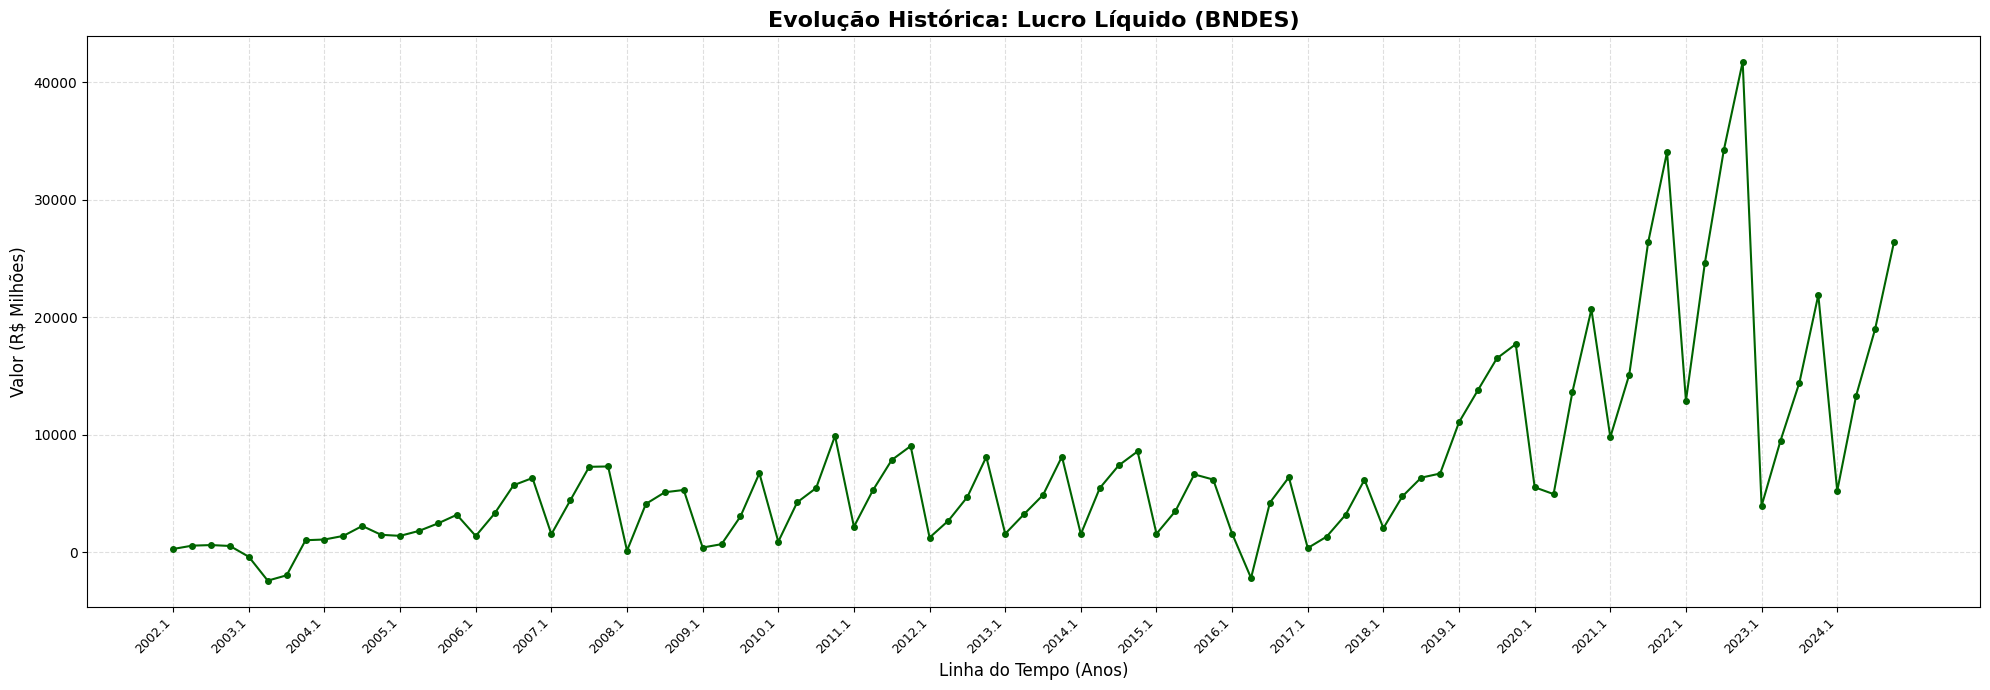

In [7]:
# =========================
# Gráfico de linha (tendência)
# =========================

# Busca os dados
nome_conta = 'Lucro Líquido'
filtro_evolucao = dados[dados.iloc[:, 0].str.contains(nome_conta, case=False, na=False)]

if not filtro_evolucao.empty:
    anos = dados.columns[1:]
    valores = filtro_evolucao.iloc[0, 1:].values.astype(float)


    plt.figure(figsize=(20, 7))
    
    # Configuração da Plotagem: Visualização da evolução histórica (2002-2024).
    # O objetivo é identificar o comportamento de crescimento e volatilidade do banco.
    plt.plot(anos, valores, marker='o', markersize=4, linestyle='-', color='darkgreen', linewidth=1.5)

    n = 4  
    plt.xticks(anos[::n], rotation=45, ha='right', fontsize=9)

    plt.title(f"Evolução Histórica: {nome_conta} (BNDES)", fontsize=16, fontweight='bold')
    plt.xlabel("Linha do Tempo (Anos)", fontsize=12)
    plt.ylabel("Valor (R$ Milhões)", fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    plt.savefig(os.path.join(PASTA_RESULTADOS, "evolucao_longa.png"), dpi=300)
    plt.show()

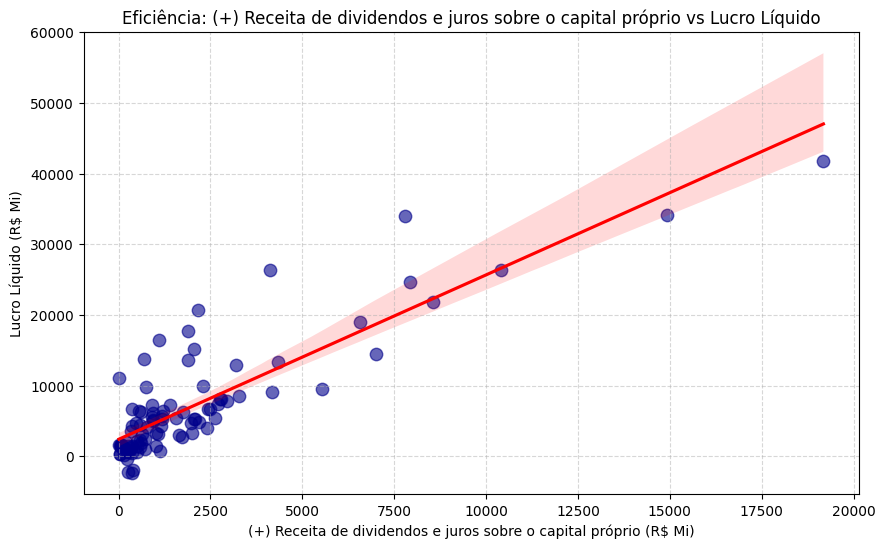

In [8]:
# Lista todas as contas que contêm as palavras que queremos
# Assim não erramos o nome por causa de um espaço ou acento
filtro_receita = dados[dados.iloc[:, 0].str.contains('Receita', case=False, na=False)]
filtro_lucro = dados[dados.iloc[:, 0].str.contains('Lucro Líquido', case=False, na=False)]

# Verificação de segurança:
if filtro_receita.empty or filtro_lucro.empty:
    print("ERRO: Não encontrei as contas. Verifique os nomes abaixo:")
    print("Opções de Receita encontradas:", filtro_receita.iloc[:,0].tolist())
    print("Opções de Lucro encontradas:", filtro_lucro.iloc[:,0].tolist())
else:
    # Pegamos a primeira ocorrência de cada um
    x_valores = filtro_receita.iloc[0, 1:].values.astype(float)
    y_valores = filtro_lucro.iloc[0, 1:].values.astype(float)
    
    nome_x = filtro_receita.iloc[0, 0]
    nome_y = filtro_lucro.iloc[0, 0]

    # Cria o gráfico
    plt.figure(figsize=(10, 6))
    sns.regplot(x=x_valores, y=y_valores, 
                scatter_kws={'s': 80, 'alpha': 0.6, 'color': 'darkblue'}, 
                line_kws={'color': 'red', 'label': 'Tendência'})

    plt.title(f"Eficiência: {nome_x} vs {nome_y}", fontsize=12)
    plt.xlabel(f"{nome_x} (R$ Mi)")
    plt.ylabel(f"{nome_y} (R$ Mi)")
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.savefig(os.path.join(PASTA_RESULTADOS, "eficiencia_final.png"))
    plt.show()


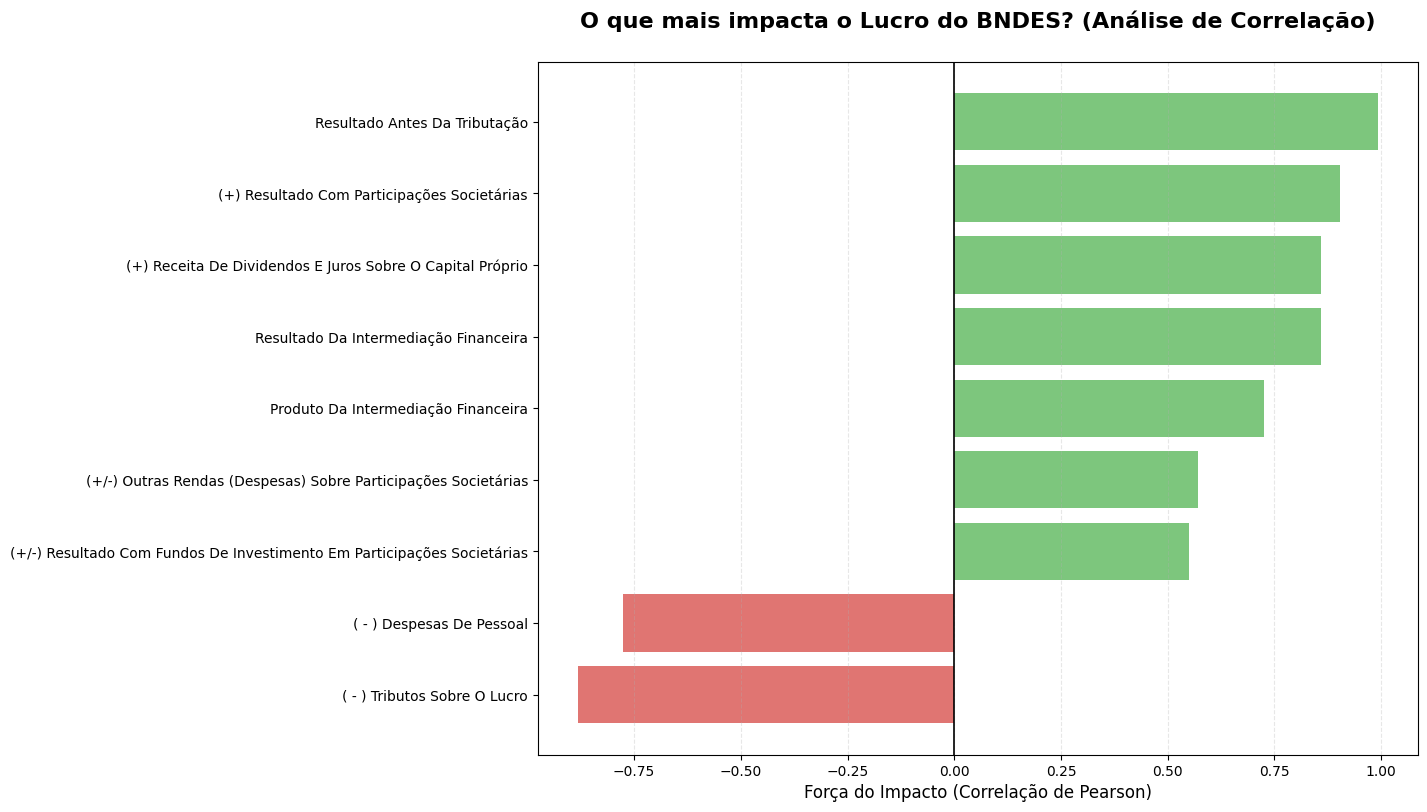

In [ ]:
# ==========================================
# MATRIZ DE CORRELAÇÃO 
# ==========================================


# Padronização total (Nomes de colunas e linhas em minúsculo e sem espaços) 
dados.columns = [c.lower().strip() for c in dados.columns]
col_contas = [c for c in dados.columns if 'conta' in c.lower()][0]
dados[col_contas] = dados[col_contas].astype(str).str.lower().str.strip()

# Busca Dinâmica de Contas (Aumentamos a lista para garantir o Imposto)
termos_chave = ['imposto', 'tributo', 'pessoal', 'alienação', 'intermed', 'dividendo', 'societária', 'tributação', 'lucro líquido']
contas_alvo = []

for termo in termos_chave:
    correspondencias = [idx for idx in dados[col_contas].unique() if termo in idx]
    contas_alvo.extend(correspondencias)

# Criamos o DataFrame de análise apenas com as contas encontradas
df_analise = dados[dados[col_contas].isin(set(contas_alvo))].set_index(col_contas)

# Definição do Alvo (Lucro Líquido)
try:
    target = [idx for idx in df_analise.index if 'lucro' in idx and 'líquido' in idx][0]
except:
    target = df_analise.index[-1]

#Cálculo da Correlação
correlacao = df_analise.T.corr()[target].sort_values(ascending=True)
correlacao = correlacao.drop(target)


tradutor = {
    'impostos sobre lucro': 'Impostos sobre Lucro',
    'gastos com pessoal': 'Gastos com Pessoal',
    'despesas de pessoal': 'Despesas de Pessoal',
    'res. antes da tributação': 'Resultado antes da Tributação'
}


correlacao.index = [tradutor.get(n, n.title()) for n in correlacao.index]


plt.figure(figsize=(16, 9), dpi=100)
colors = ['#5cb85c' if x > 0 else '#d9534f' for x in correlacao.values]

plt.barh(correlacao.index, correlacao.values, color=colors, alpha=0.8)


plt.title("O que mais impacta o Lucro do BNDES? (Análise de Correlação)", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("Força do Impacto (Correlação de Pearson)", fontsize=12)
plt.axvline(0, color='black', linewidth=1.2)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.subplots_adjust(left=0.35)

plt.savefig(os.path.join(PASTA_RESULTADOS, "impacto_lucro.png"))
plt.show()

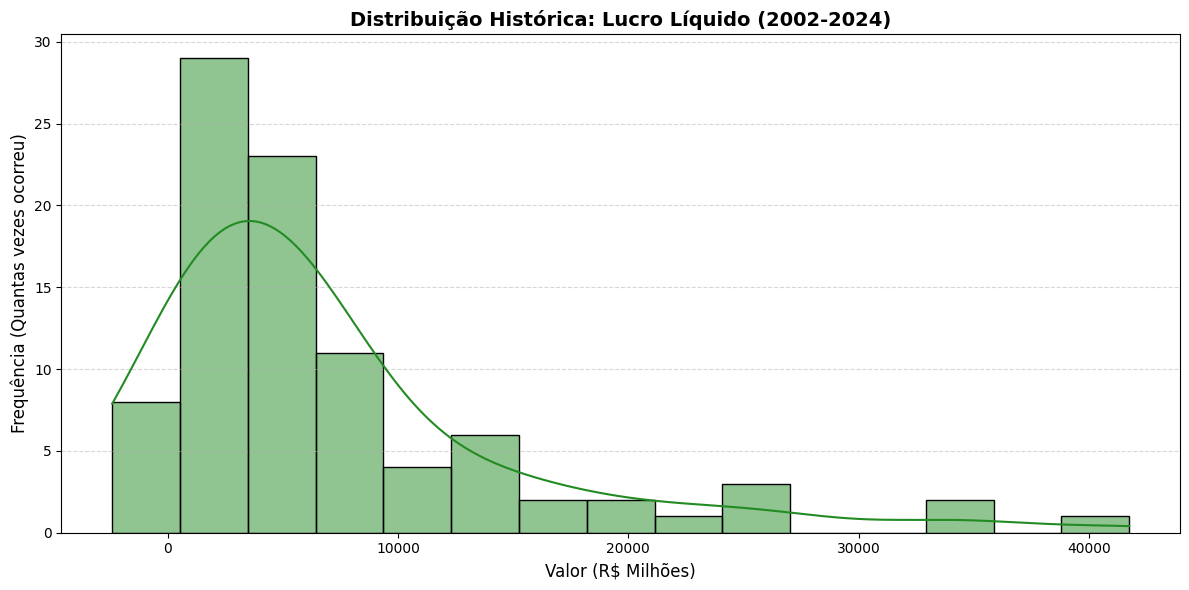

In [10]:
# =========================
# Histograma (distribuição)
# =========================
# Escolhemos a conta para ver a distribuição histórica
nome_conta = 'Lucro Líquido'
filtro_dist = dados[dados.iloc[:, 0].str.contains(nome_conta, case=False, na=False)]

if not filtro_dist.empty:
    # Pegamos TODOS os valores (de 2002 a 2024) e transformamos em uma lista só
    todos_os_valores = filtro_dist.iloc[0, 1:].values.astype(float)

    plt.figure(figsize=(12, 6))
    
    # Criamos o histograma com a linha de densidade (KDE)
    sns.histplot(todos_os_valores, kde=True, color='forestgreen', bins=15)

    plt.title(f"Distribuição Histórica: {nome_conta} (2002-2024)", fontsize=14, fontweight='bold')
    plt.xlabel("Valor (R$ Milhões)", fontsize=12)
    plt.ylabel("Frequência (Quantas vezes ocorreu)", fontsize=12)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(PASTA_RESULTADOS, "historico_lucro.png"))
    plt.show()


## Conclusão
Resumo da Análise (BNDES 2002-2024)

**O Banco está crescendo:** O gráfico de linha mostra que, apesar de altos e baixos, o BNDES deu um salto gigante de lucro nos últimos anos. Ele não é mais o mesmo banco de 20 anos atrás; hoje ele é muito mais lucrativo.

**O segredo do lucro (Venda de Ações):** O gráfico de barras revelou que o que mais faz o BNDES ganhar dinheiro não é apenas emprestar para empresas, mas sim vender as ações que ele tem de outras empresas (como Petrobras e Vale). Quando ele vende essas participações, o lucro explode.

**Os "vilões" do resultado:** Como era de se esperar, Impostos e Gastos com Pessoal são os fatores que mais puxam o resultado para baixo. Quanto mais o banco gasta internamente, menor é a sobra final.

**Comportamento Padrão:** O histograma nos mostra que o banco é consistente. Ele tem um lucro "normal" na maior parte do tempo, mas tem uma capacidade incrível de ter anos "fora da curva" com ganhos extraordinários.